# Data Exploration - Support Ticket Classification

This notebook explores the IT Service Ticket Classification Dataset to understand:
- Dataset structure and size
- Ticket categories and distribution
- Text characteristics
- Data quality issues
- Initial insights for preprocessing

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 1. Load Dataset

In [2]:

data_path = '../data/tickets.csv'  

try:
    df = pd.read_csv(data_path)
    print(f"✓ Dataset loaded successfully!")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {list(df.columns)}")
except FileNotFoundError:
    print("❌ Dataset not found!")
    

✓ Dataset loaded successfully!
  Shape: (8469, 17)
  Columns: ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


In [3]:

df.head(10)

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0
5,6,Rebecca Fleming,sheenasmith@example.com,53,Male,Microsoft Office,2020-07-28,Cancellation request,Payment issue,I'm facing a problem with my {product_purchase...,Open,NaN,Low,Social media,NaN,NaN,NaN
6,7,Jacqueline Wright,donaldkeith@example.org,24,Other,Microsoft Surface,2020-02-23,Product inquiry,Refund request,I'm unable to access my {product_purchased} ac...,Open,NaN,Critical,Social media,NaN,NaN,NaN
7,8,Denise Lee,joelwilliams@example.com,23,Male,Philips Hue Lights,2020-08-09,Refund request,Battery life,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Social media,NaN,NaN,NaN
8,9,Nicolas Wilson,joshua24@example.com,60,Other,Fitbit Versa Smartwatch,2020-07-16,Technical issue,Installation support,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Low,Social media,2023-06-01 10:32:47,NaN,NaN
9,10,William Dawson,clopez@example.com,27,Male,Dyson Vacuum Cleaner,2020-03-06,Refund request,Payment issue,My {product_purchased} is making strange noise...,Pending Customer Response,NaN,Critical,Phone,2023-06-01 09:25:48,NaN,NaN


## 2. Basic Dataset Information

In [4]:

print("Dataset Information:")
print("="*60)
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-nu

In [5]:

print("\nDataset Statistics:")
print("="*60)
print(f"Total tickets: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Dataset Statistics:
Total tickets: 8,469
Total columns: 17
Memory usage: 9.90 MB


In [6]:

print("\nMissing Values:")
print("="*60)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

if missing.sum() == 0:
    print("✓ No missing values found!")


Missing Values:
                              Missing Count  Percentage
Resolution                             5700   67.304286
First Response Time                    2819   33.286102
Time to Resolution                     5700   67.304286
Customer Satisfaction Rating           5700   67.304286


In [7]:

duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")
if duplicates > 0:
    print(f"  Percentage: {(duplicates/len(df))*100:.2f}%")


Duplicate rows: 0


## 3. Ticket Category Analysis

In [8]:
# Identify the category column (adjust based on actual column name)
# Common names: 'category', 'type', 'class', 'label', 'ticket_type'
category_col = None
for col in df.columns:
    if any(keyword in col.lower() for keyword in ['category', 'type', 'class', 'label']):
        category_col = col
        break

if category_col:
    print(f"Category column: {category_col}")
    print(f"\nUnique categories: {df[category_col].nunique()}")
    print(f"\nCategory distribution:")
    print(df[category_col].value_counts())
else:
    print("⚠️ Category column not automatically detected.")
    print("Available columns:", list(df.columns))
    print("\nPlease manually set: category_col = 'your_column_name'")

Category column: Ticket Type

Unique categories: 5

Category distribution:
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


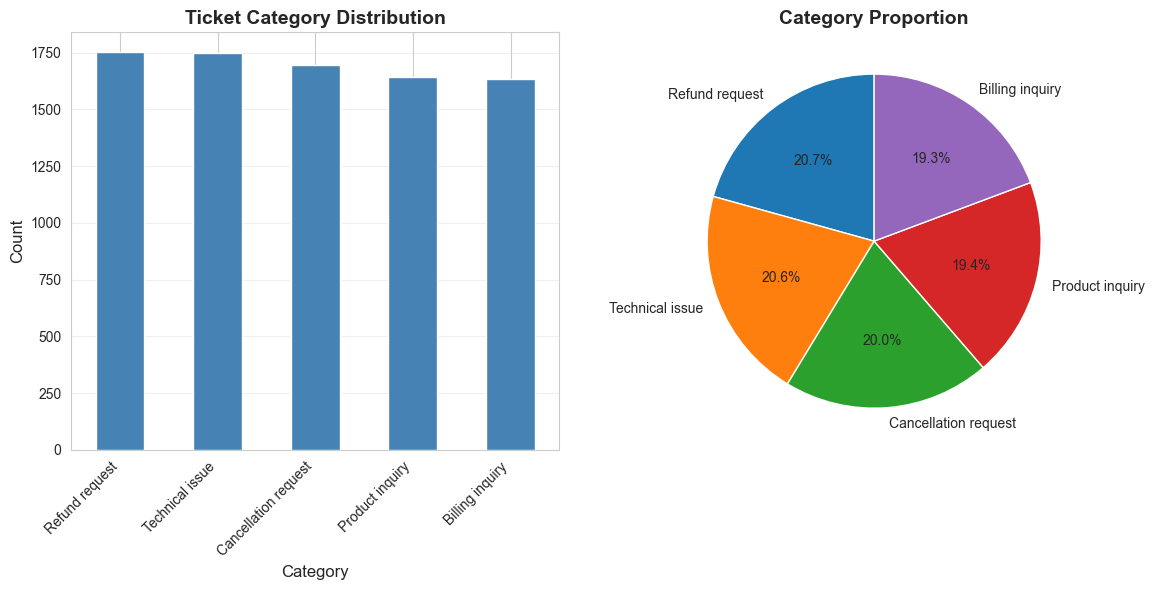

✓ Plot saved to: outputs/category_distribution.png


In [9]:
# Visualize category distribution
if category_col:
    plt.figure(figsize=(12, 6))
    
    category_counts = df[category_col].value_counts()
    
    # Bar plot
    plt.subplot(1, 2, 1)
    category_counts.plot(kind='bar', color='steelblue')
    plt.title('Ticket Category Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Category', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    
    # Pie chart
    plt.subplot(1, 2, 2)
    category_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
    plt.title('Category Proportion', fontsize=14, fontweight='bold')
    plt.ylabel('')
    
    plt.tight_layout()
    plt.savefig('../outputs/category_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Plot saved to: outputs/category_distribution.png")

## 4. Text Analysis

In [10]:
# Identify text column (adjust based on actual column name)
text_col = None
for col in df.columns:
    if any(keyword in col.lower() for keyword in ['description', 'text', 'message', 'content', 'body']):
        text_col = col
        break

if text_col:
    print(f"Text column: {text_col}")
else:
    print("⚠️ Text column not automatically detected.")
    print("Available columns:", list(df.columns))
    print("\nPlease manually set: text_col = 'your_column_name'")

Text column: Ticket Description


In [11]:
# Text length analysis
if text_col:
    df['text_length'] = df[text_col].astype(str).str.len()
    df['word_count'] = df[text_col].astype(str).str.split().str.len()
    
    print("Text Statistics:")
    print("="*60)
    print(f"Average text length: {df['text_length'].mean():.2f} characters")
    print(f"Median text length: {df['text_length'].median():.2f} characters")
    print(f"Average word count: {df['word_count'].mean():.2f} words")
    print(f"Median word count: {df['word_count'].median():.2f} words")
    print(f"\nMin text length: {df['text_length'].min()} characters")
    print(f"Max text length: {df['text_length'].max()} characters")

Text Statistics:
Average text length: 289.82 characters
Median text length: 298.00 characters
Average word count: 46.47 words
Median word count: 49.00 words

Min text length: 151 characters
Max text length: 397 characters


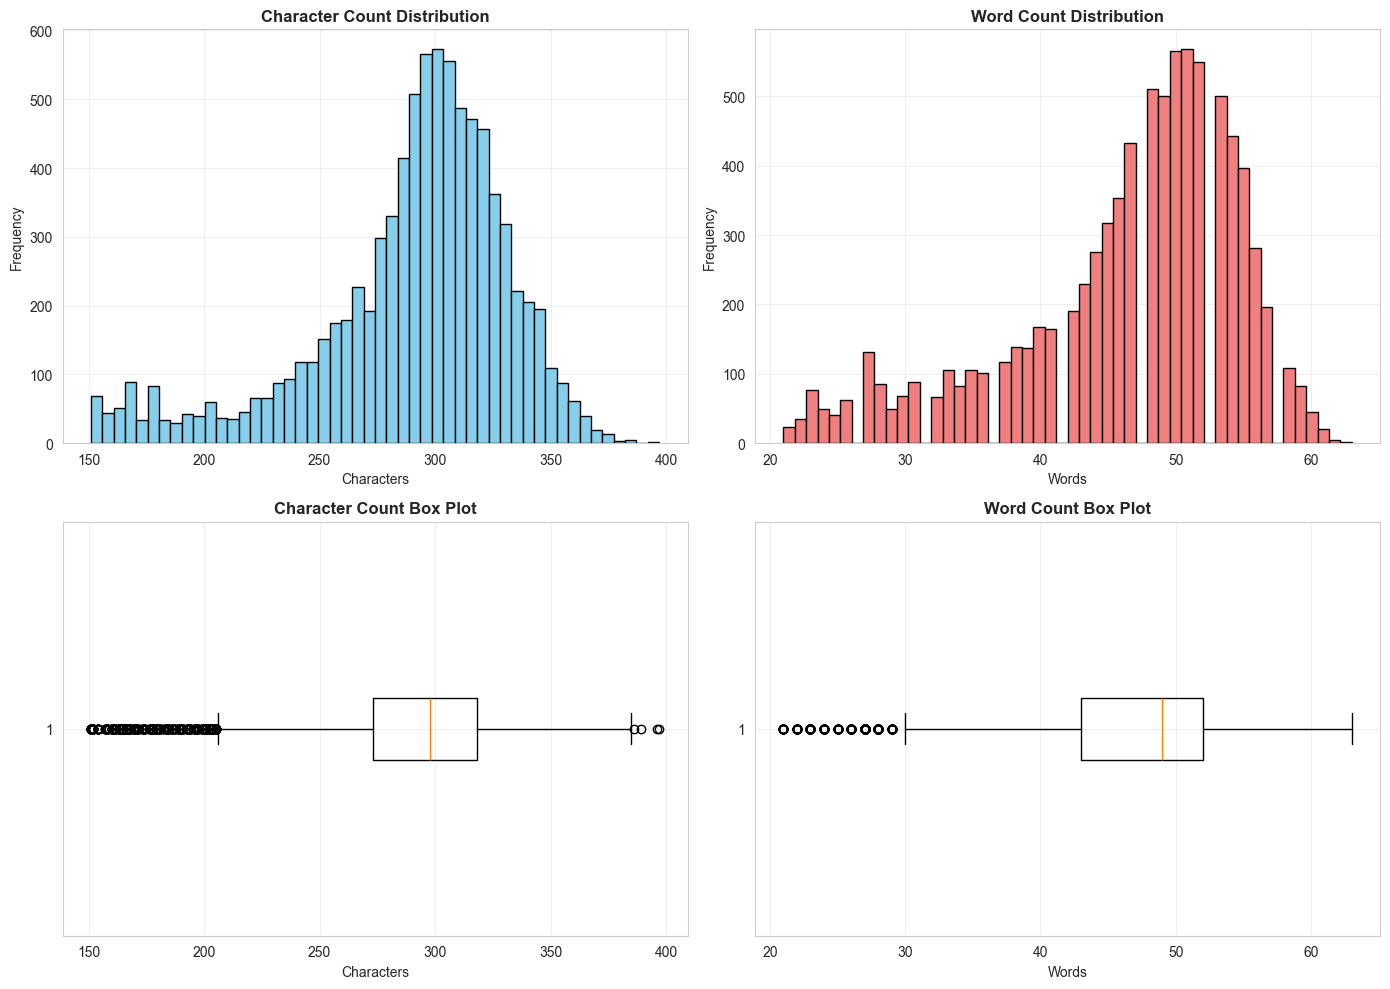

✓ Plot saved to: outputs/text_length_analysis.png


In [12]:
# Visualize text length distribution
if text_col:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Character count distribution
    axes[0, 0].hist(df['text_length'], bins=50, color='skyblue', edgecolor='black')
    axes[0, 0].set_title('Character Count Distribution', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Characters')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].grid(alpha=0.3)
    
    # Word count distribution
    axes[0, 1].hist(df['word_count'], bins=50, color='lightcoral', edgecolor='black')
    axes[0, 1].set_title('Word Count Distribution', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Words')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].grid(alpha=0.3)
    
    # Box plot - character count
    axes[1, 0].boxplot(df['text_length'], vert=False)
    axes[1, 0].set_title('Character Count Box Plot', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Characters')
    axes[1, 0].grid(alpha=0.3)
    
    # Box plot - word count
    axes[1, 1].boxplot(df['word_count'], vert=False)
    axes[1, 1].set_title('Word Count Box Plot', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Words')
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../outputs/text_length_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Plot saved to: outputs/text_length_analysis.png")

<Figure size 1200x600 with 0 Axes>

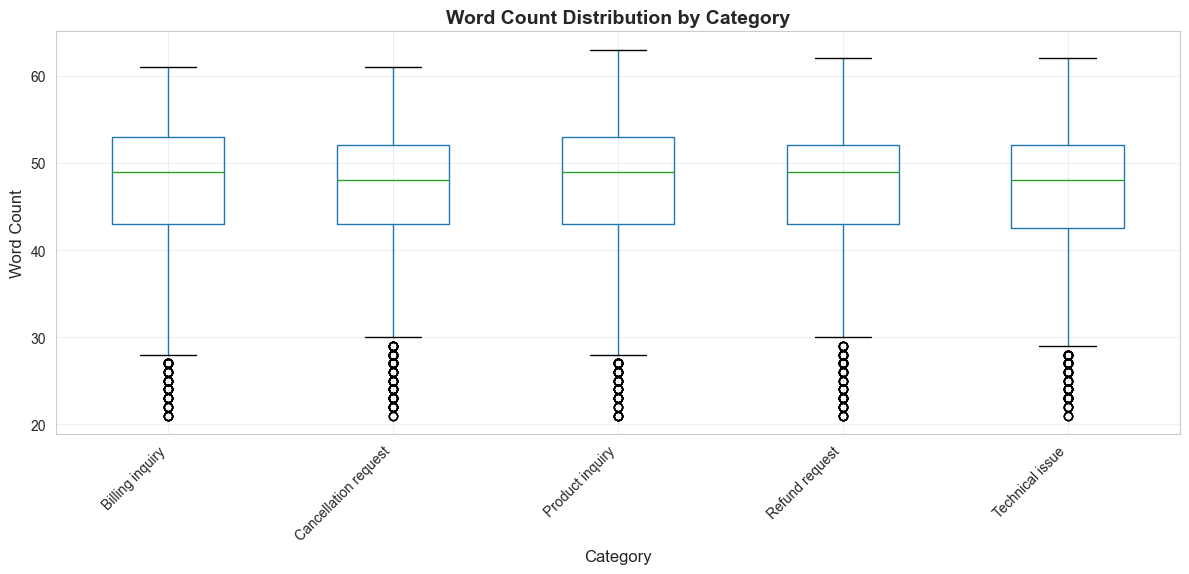

✓ Plot saved to: outputs/word_count_by_category.png


In [13]:
# Text length by category
if text_col and category_col:
    plt.figure(figsize=(12, 6))
    
    df.boxplot(column='word_count', by=category_col, figsize=(12, 6))
    plt.title('Word Count Distribution by Category', fontsize=14, fontweight='bold')
    plt.suptitle('')  # Remove default title
    plt.xlabel('Category', fontsize=12)
    plt.ylabel('Word Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../outputs/word_count_by_category.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Plot saved to: outputs/word_count_by_category.png")

## 5. Word Cloud Visualization

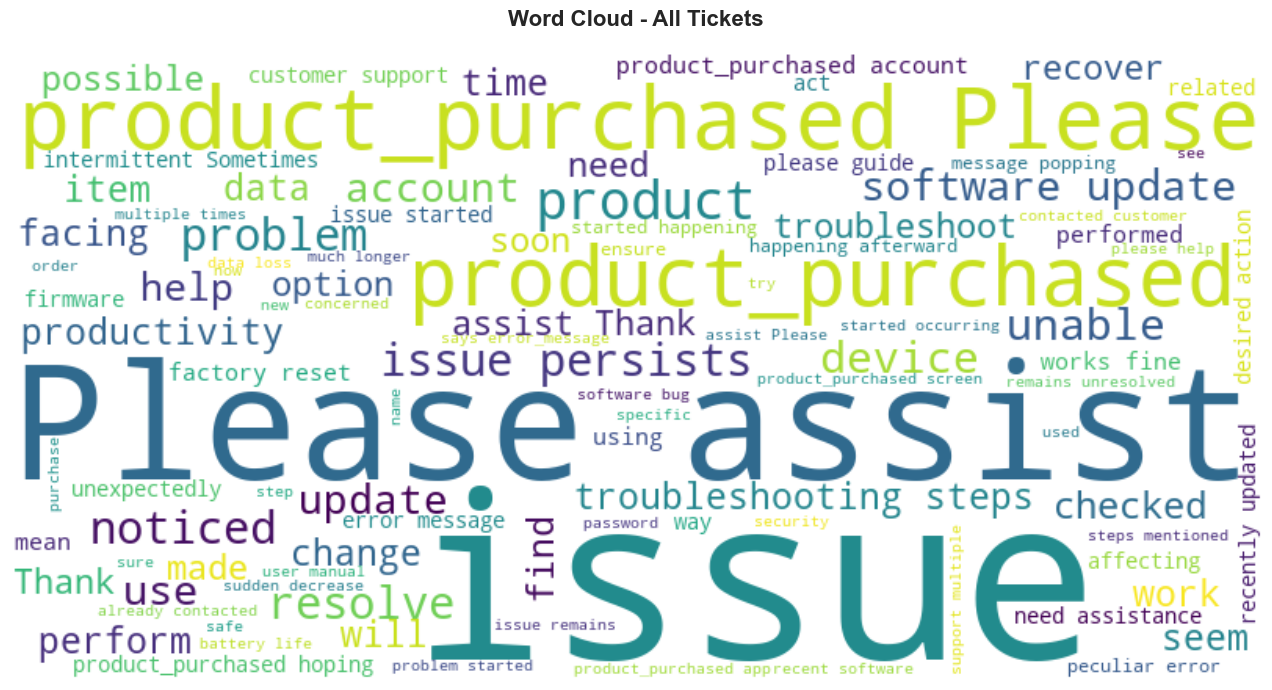

✓ Word cloud saved to: outputs/wordcloud_all.png


In [14]:
# Overall word cloud
if text_col:
    all_text = ' '.join(df[text_col].astype(str).values)
    
    wordcloud = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap='viridis',
        max_words=100
    ).generate(all_text)
    
    plt.figure(figsize=(14, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud - All Tickets', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('../outputs/wordcloud_all.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Word cloud saved to: outputs/wordcloud_all.png")

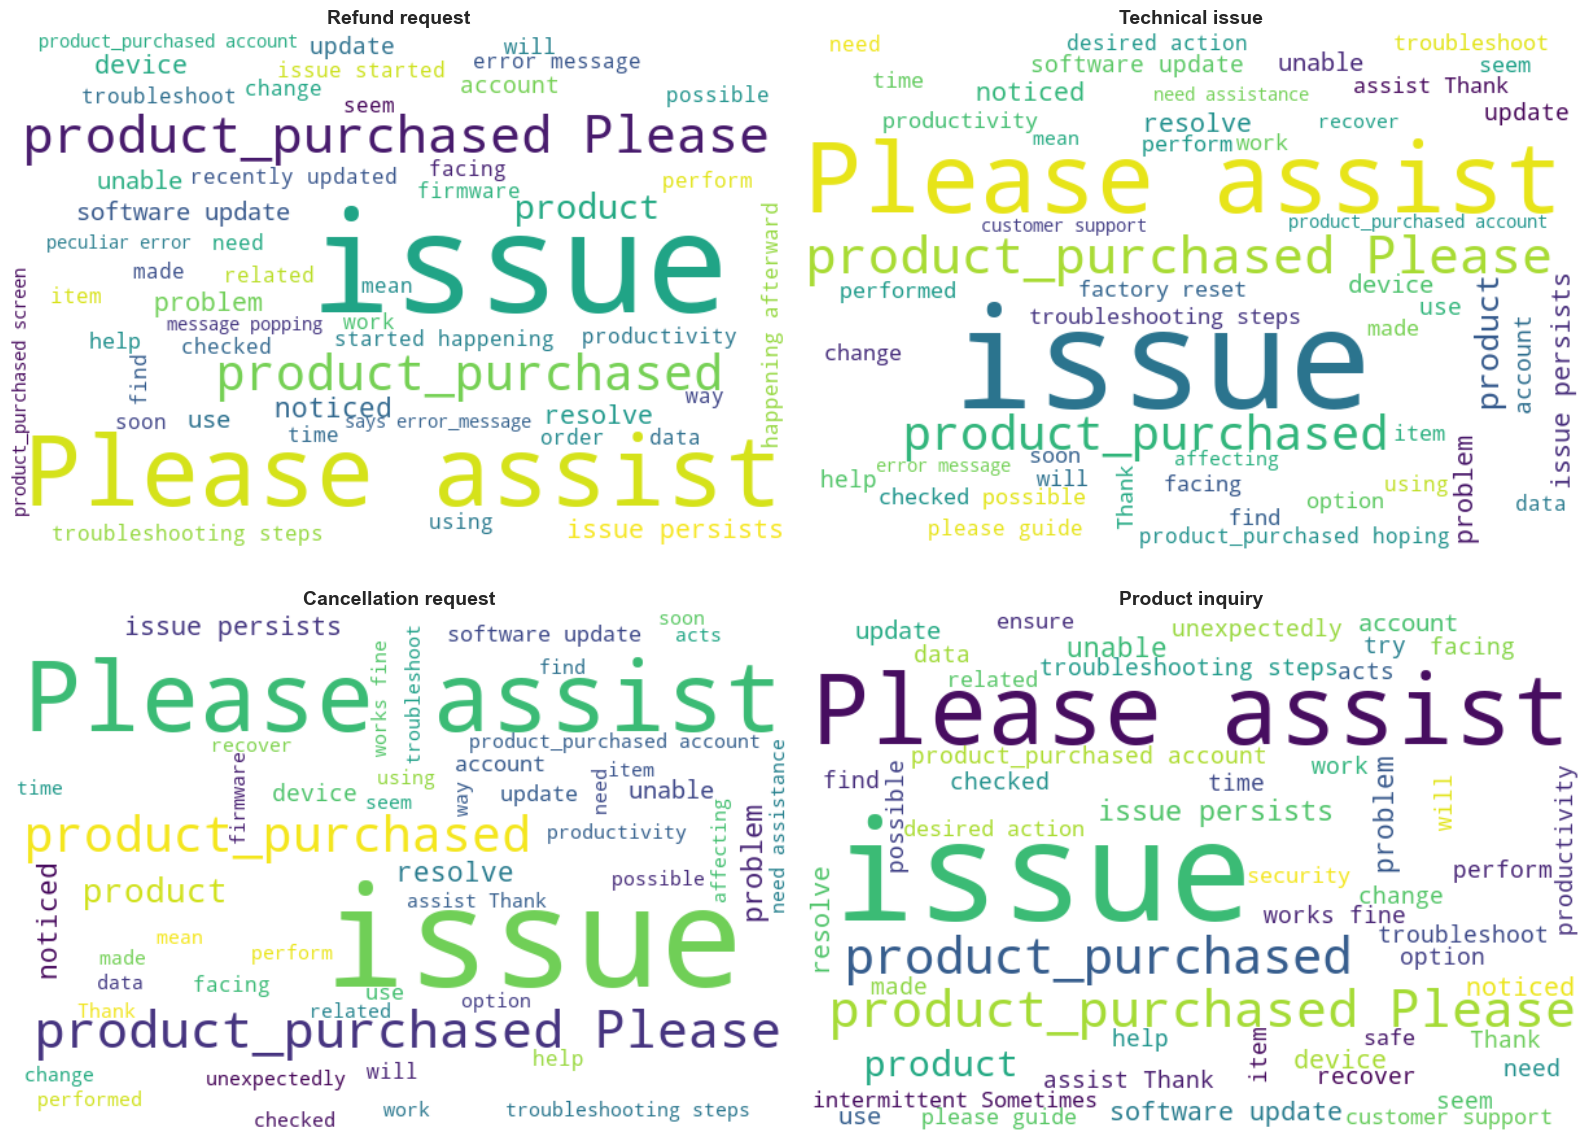

✓ Word clouds saved to: outputs/wordcloud_by_category.png


In [15]:
# Word clouds by category
if text_col and category_col:
    categories = df[category_col].value_counts().head(4).index  # Top 4 categories
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()
    
    for idx, category in enumerate(categories):
        if idx >= 4:
            break
            
        category_text = ' '.join(
            df[df[category_col] == category][text_col].astype(str).values
        )
        
        wordcloud = WordCloud(
            width=600, height=400,
            background_color='white',
            colormap='viridis',
            max_words=50
        ).generate(category_text)
        
        axes[idx].imshow(wordcloud, interpolation='bilinear')
        axes[idx].axis('off')
        axes[idx].set_title(f'{category}', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../outputs/wordcloud_by_category.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Word clouds saved to: outputs/wordcloud_by_category.png")

## 6. Sample Tickets

In [16]:
# Display sample tickets from each category
if text_col and category_col:
    print("Sample Tickets by Category:")
    print("="*80)
    
    for category in df[category_col].unique()[:5]:  # First 5 categories
        print(f"\n{category.upper()}:")
        print("-"*80)
        
        samples = df[df[category_col] == category][text_col].head(2)
        for i, text in enumerate(samples, 1):
            print(f"  {i}. {str(text)[:200]}...")
            print()

Sample Tickets by Category:

TECHNICAL ISSUE:
--------------------------------------------------------------------------------
  1. I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I'...

  2. I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing product.

I'm having an issue with the {product_purchased}. Please assist.

If The issue I'm facing ...


BILLING INQUIRY:
--------------------------------------------------------------------------------
  1. I'm having an issue with the {product_purchased}. Please assist.

If you have a problem you're interested in and I'd love to see this happen, please check out the Feedback. I've already contacted cust...

  2. I'm having an issue with the {product_purchased}. Please assist.


Note: The seller is not responsible for any damages arising out of the d

## 7. Key Insights & Next Steps

In [17]:
print("KEY INSIGHTS:")
print("="*80)
print(f"✓ Total tickets: {len(df):,}")

if category_col:
    print(f"✓ Number of categories: {df[category_col].nunique()}")
    print(f"✓ Most common category: {df[category_col].value_counts().index[0]}")
    print(f"✓ Least common category: {df[category_col].value_counts().index[-1]}")

if text_col:
    print(f"✓ Average ticket length: {df['word_count'].mean():.0f} words")
    print(f"✓ Shortest ticket: {df['word_count'].min()} words")
    print(f"✓ Longest ticket: {df['word_count'].max()} words")

print(f"\nDATA QUALITY:")
print(f"✓ Missing values: {df.isnull().sum().sum()}")
print(f"✓ Duplicate rows: {df.duplicated().sum()}")

print(f"\nNEXT STEPS:")
print("1. Text preprocessing (cleaning, stopword removal, lemmatization)")
print("2. Create priority labels based on ticket characteristics")
print("3. Feature extraction (TF-IDF, BoW)")
print("4. Model training and evaluation")

KEY INSIGHTS:
✓ Total tickets: 8,469
✓ Number of categories: 5
✓ Most common category: Refund request
✓ Least common category: Billing inquiry
✓ Average ticket length: 46 words
✓ Shortest ticket: 21 words
✓ Longest ticket: 63 words

DATA QUALITY:
✓ Missing values: 19919
✓ Duplicate rows: 0

NEXT STEPS:
1. Text preprocessing (cleaning, stopword removal, lemmatization)
2. Create priority labels based on ticket characteristics
3. Feature extraction (TF-IDF, BoW)
4. Model training and evaluation


In [18]:
# Save exploration summary
summary = {
    'total_tickets': len(df),
    'num_categories': df[category_col].nunique() if category_col else None,
    'avg_word_count': df['word_count'].mean() if text_col else None,
    'missing_values': df.isnull().sum().sum(),
    'duplicates': df.duplicated().sum(),
    'text_column': text_col,
    'category_column': category_col
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv('../data/processed/exploration_summary.csv', index=False)

print("✓ Exploration summary saved to: data/processed/exploration_summary.csv")

✓ Exploration summary saved to: data/processed/exploration_summary.csv
